## ML&Fintech HW8 Chapter 6 Q8

Name: Alvin B. Lin\
ID: 112652040\
Date: 21/11/2025\
HW #: 8

8.In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its `normal()` method to generate a predictor `X` of length $n = 100$, as well as a noise vector $\varepsilon$ of length $n = 100$.

In [ ]:
import random
import numpy as np

random.seed(42)
# generate a 100 * 1 vector by normal
X = np.random.normal(loc=0.0, scale=1.0, size=(100, 1))
# generate noise
epsilon = np.random.normal(loc=0.0, scale=1.0, size=(100, 1))
# coefficients
print(f'Length of X = {len(X)}; length of noise = {len(epsilon)}')

Length of X = 100; length of noise = 100


(b) Generate a response vector `Y` of length $n = 100$ according to the model $$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \varepsilon,$$ where $\beta_i,\;i = 0,\ldots, 3$ are constance of your choice.

In [6]:
Y = 3 + 2 * X + 0.5 * X**2 - 1 * X**3 + epsilon
print(f'beta_0 = 3, beta_1 = 2, beta_2 = 0.5, beta_3 = -1')
print(f'Length of Y = {len(Y)}')

beta_0 = 3, beta_1 = 2, beta_2 = 0.5, beta_3 = -1
Length of Y = 100


(c) Use forward stepwise selection in order to select a model containing the predictors $X,\;X^2\;,...,\;X^{10}.$ What is the model obtained according to $C_p$? Report the coefficients of the model obtained.

$$C_p = \frac{1}{n}\left(\text{RSS} + 2d\hat\sigma^2\right)$$

In [8]:
def nCp(sigma2, estimator, X, Y):
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y- Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

cols = ['x'+str(i) for i in range(1, 11)] + ['Y']
X_df = pd.DataFrame(np.concatenate((X_poly,Y), axis=1), columns=cols)
X_df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,Y
0,0.650697,0.423406,0.275509,0.179273,0.116652,7.590521e-02,4.939127e-02,3.213873e-02,2.091257e-02,1.360774e-02,5.088016
1,0.092966,0.008643,0.000803,0.000075,0.000007,6.455773e-07,6.001682e-08,5.579531e-09,5.187073e-10,4.822221e-11,3.933332
2,1.559464,2.431929,3.792506,5.914277,9.223103,1.438310e+01,2.242993e+01,3.497867e+01,5.454798e+01,8.506562e+01,4.163444
3,2.165617,4.689899,10.156527,21.995151,47.633083,1.031550e+02,2.233943e+02,4.837867e+02,1.047697e+03,2.268911e+03,-1.824936
4,-0.320318,0.102603,-0.032866,0.010527,-0.003372,1.080153e-03,-3.459921e-04,1.108274e-04,-3.549997e-05,1.137127e-05,3.375200


In [16]:
import statsmodels.api as sm
from itertools import combinations
from tqdm import tqdm

def process_linear_model(subset, data, response):
    x_train = sm.add_constant(data[subset])
    model = sm.OLS(response, x_train).fit()
    train_RSS = model.ssr
    return (model, train_RSS)

def find_best_subset(data, response, max_features, operation):
    best_sub_list = []
    best_model = []
    num_of_features = []
    
    for k in tqdm(range(1, max_features+1)):
        best_rss = np.inf
        best_kth_model = None
        
        subsets = combinations(data.columns, k)
        
        for subset in subsets:
            result = process_linear_model(list(subset), data, response)
            if result[1] < best_rss:
                best_rss = result[1]
                best_subset = list(subset)
                best_kth_model = result[0]
                
        num_of_features.append(k)
        best_sub_list.append(best_subset)
        best_model.append(best_kth_model)
            
    results = pd.DataFrame({'sub': best_sub_list, 'model': best_model})
    results.to_pickle(f'C://Users/benny/Document/{operation}.pkl')
    return results

In [17]:
X = X_df.drop(['Y'], axis=1)
Y = X_df.Y

bestsub_results = find_best_subset(X, Y, 10, 'poly_bestsub')

100%|██████████| 10/10 [00:02<00:00,  4.53it/s]


In [18]:
bestsub_results

,sub,model
0,[x5],<statsmodels.regression.linear_model.Regressio...
1,"[x1, x3]",<statsmodels.regression.linear_model.Regressio...
2,"[x1, x2, x3]",<statsmodels.regression.linear_model.Regressio...
3,"[x1, x2, x3, x4]",<statsmodels.regression.linear_model.Regressio...
4,"[x1, x2, x3, x8, x9]",<statsmodels.regression.linear_model.Regressio...
5,"[x1, x2, x3, x5, x7, x10]",<statsmodels.regression.linear_model.Regressio...
6,"[x1, x2, x3, x4, x6, x8, x10]",<statsmodels.regression.linear_model.Regressio...
7,"[x1, x2, x3, x4, x6, x7, x8, x9]",<statsmodels.regression.linear_model.Regressio...
8,"[x1, x2, x3, x4, x5, x6, x7, x8, x9]",<statsmodels.regression.linear_model.Regressio...
9,"[x1, x2, x3, x4, x5, x6, x7, x8, x9, x10]",<statsmodels.regression.linear_model.Regressio...


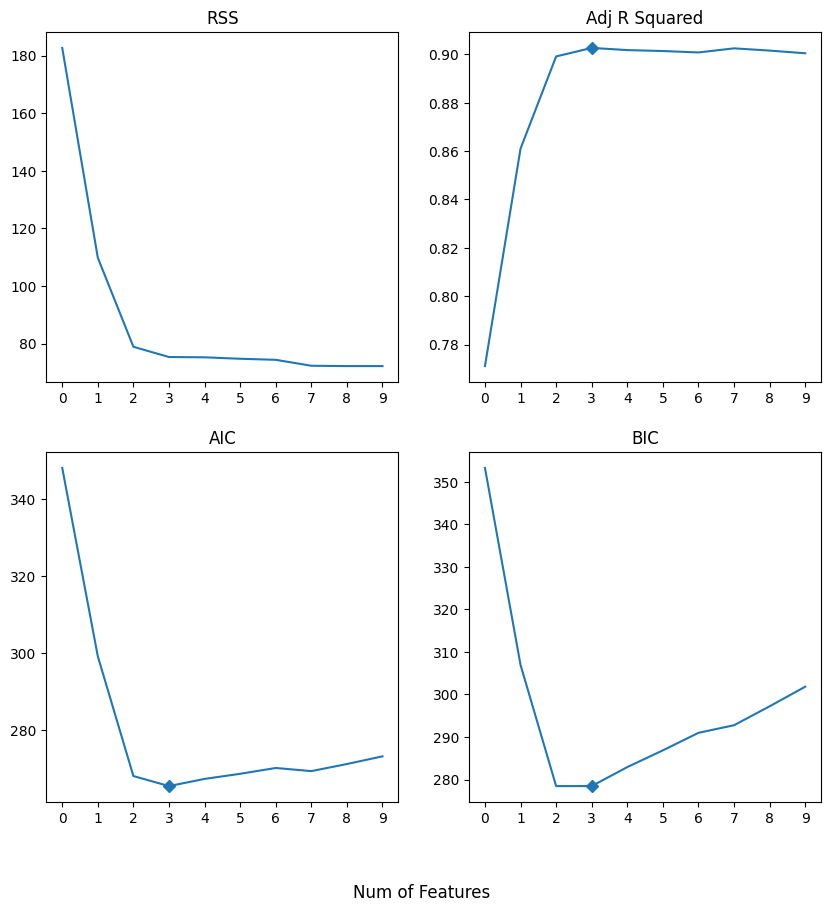

In [20]:
import matplotlib.pyplot as plt

aic = [bestsub_results.model[i].aic for i in range(0, len(bestsub_results.model))]
bic = [bestsub_results.model[i].bic for i in range(0, len(bestsub_results.model))]
r2_adj = [bestsub_results.model[i].rsquared_adj for i in range(0, len(bestsub_results.model))]
rss = [bestsub_results.model[i].ssr for i in range(0, len(bestsub_results.model))]
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.supxlabel('Num of Features')

axes[0, 0].plot(rss)
axes[0, 0].set_title('RSS')
axes[0, 0].set_xticks(np.arange(0, 10, 1))

axes[0, 1].plot(r2_adj, markevery=[np.argmax(r2_adj)], marker='D')
axes[0, 1].set_title('Adj R Squared')
axes[0, 1].set_xticks(np.arange(0, 10, 1))

axes[1, 0].plot(aic, markevery=[np.argmin(aic)], marker='D')
axes[1, 0].set_title('AIC')
axes[1, 0].set_xticks(np.arange(0, 10, 1))

axes[1, 1].plot(bic, markevery=[np.argmin(bic)], marker='D')
axes[1, 1].set_title('BIC')
axes[1, 1].set_xticks(np.arange(0, 10, 1))

In [24]:
# get the best model based on BIC
best_bic_model = bestsub_results.model[3]
best_bic_model.params

const    2.939885
x1       2.208216
x2       0.790866
x3      -1.066574
x4      -0.076761
dtype: float64

$\implies$ best model is $\hat Y = 2.939885 + 2.208216X + 0.790866 X^2 -1.066574X^3 - 0.076761X^4$

In [25]:
def forward_stepwise(X, y, max_features):
    models = []
    feature_list = []
    remaining_features = list(X.columns)
    
    def update_model(current_features, remaining_features):
        best_rss = np.inf
        best_model = None
        
        for new_feature in tqdm(remaining_features):
            result = process_linear_model(feature_list + [new_feature], X, y)
            if result[1] < best_rss:
                best_rss = result[1]
                best_model = result[0]

        new_feature_list = list(best_model.params.index)[1:]
        
        return new_feature_list, best_model
    
    while remaining_features and len(feature_list) < max_features:
        feature_list, best_model = update_model(feature_list, remaining_features)
        remaining_features = [x for x in list(X.columns) if x not in feature_list]
        models.append([feature_list, best_model])
        
    return models


In [26]:
bestsub_forward = forward_stepwise(X, Y, 10)

100%|██████████| 1/1 [00:00<00:00, 80.57it/s]


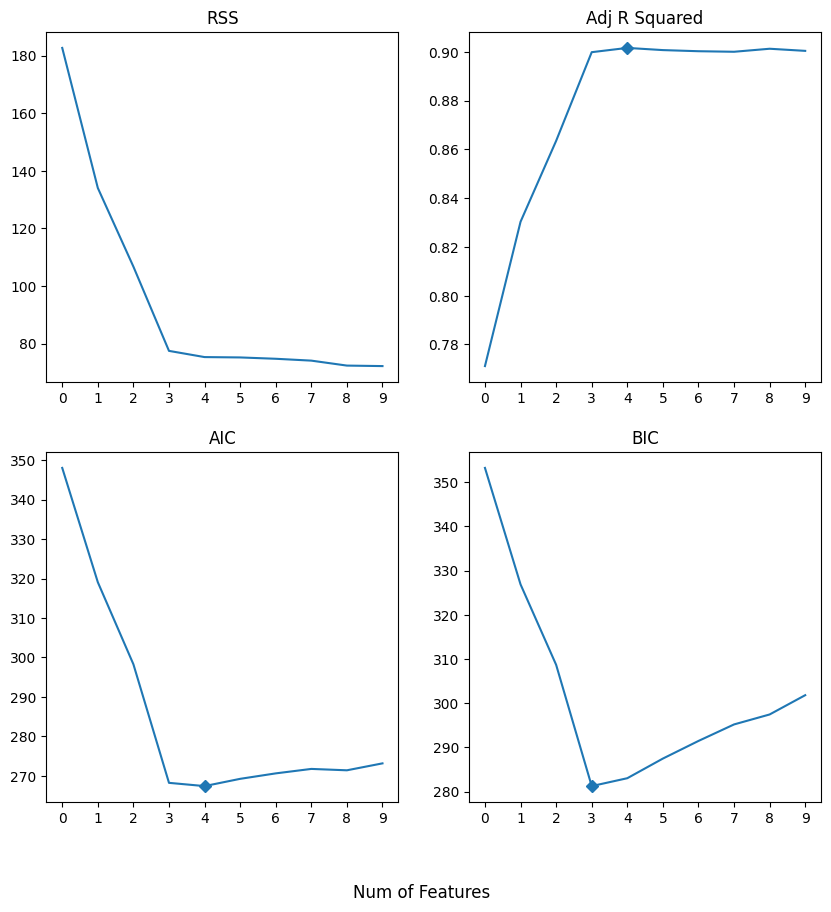

In [27]:
aic_fwd = [model[1].aic for model in bestsub_forward]
bic_fwd = [model[1].bic for model in bestsub_forward] 
r2_adj_fwd = [model[1].rsquared_adj for model in bestsub_forward]
rss_fwd = [model[1].ssr for model in bestsub_forward]
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.supxlabel('Num of Features')

axes[0, 0].plot(rss_fwd)
axes[0, 0].set_title('RSS')
axes[0, 0].set_xticks(np.arange(0, 10, 1))

axes[0, 1].plot(r2_adj_fwd, markevery=[np.argmax(r2_adj_fwd)], marker='D')
axes[0, 1].set_title('Adj R Squared')
axes[0, 1].set_xticks(np.arange(0, 10, 1))

axes[1, 0].plot(aic_fwd, markevery=[np.argmin(aic_fwd)], marker='D')
axes[1, 0].set_title('AIC')
axes[1, 0].set_xticks(np.arange(0, 10, 1))

axes[1, 1].plot(bic_fwd, markevery=[np.argmin(bic_fwd)], marker='D')
axes[1, 1].set_title('BIC')
axes[1, 1].set_xticks(np.arange(0, 10, 1))

In [28]:
print(f'Best model for R^2 and AIC is: {bestsub_forward[4]}')
print(f'Best model for BIC is: {bestsub_forward[3]}')

Best model for R^2 and AIC is: [['x5', 'x1', 'x3', 'x2', 'x4'], <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x0000020544A5CB00>]
Best model for BIC is: [['x5', 'x1', 'x3', 'x2'], <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x0000020544E88050>]


(e) Now fit a lasso model to the simulated data, again using $X,X^2, . . . , X^{10}$ as predictors. Use cross-validation to select the optimal value of λ. Create plots of the cross-validation error as a function of λ. Report the resulting coefficient estimates, and discuss the results obtained.

In [30]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, scale, StandardScaler

alphas = np.logspace(-4, -1, 100)
lassocv = LassoCV(alphas=alphas, cv=5, max_iter=100000)

lassocv.fit(scale(X), Y)

c:\Users\benny\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0916487704066995, tolerance: 0.07360757508200488
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\benny\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0797877658400381, tolerance: 0.07600092742344662
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\benny\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1235527274279491, tolerance: 0.07600092742344662
  model = cd_fast.enet_coordinate_descent_g

LassoCV(alphas=array([0.0001    , 0.00010723, 0.00011498, 0.00012328, 0.00013219,
       0.00014175, 0.00015199, 0.00016298, 0.00017475, 0.00018738,
       0.00020092, 0.00021544, 0.00023101, 0.00024771, 0.00026561,
       0.0002848 , 0.00030539, 0.00032745, 0.00035112, 0.00037649,
       0.0004037 , 0.00043288, 0.00046416, 0.0004977 , 0.00053367,
       0.00057224, 0.00061359, 0.00065793, 0.00070548, 0.00075646,
       0.000...
       0.00932603, 0.01      , 0.01072267, 0.01149757, 0.01232847,
       0.01321941, 0.01417474, 0.01519911, 0.01629751, 0.01747528,
       0.01873817, 0.02009233, 0.02154435, 0.0231013 , 0.02477076,
       0.02656088, 0.02848036, 0.03053856, 0.03274549, 0.03511192,
       0.03764936, 0.04037017, 0.04328761, 0.04641589, 0.04977024,
       0.05336699, 0.05722368, 0.06135907, 0.06579332, 0.07054802,
       0.07564633, 0.08111308, 0.0869749 , 0.09326033, 0.1       ]),
        cv=5, max_iter=100000)

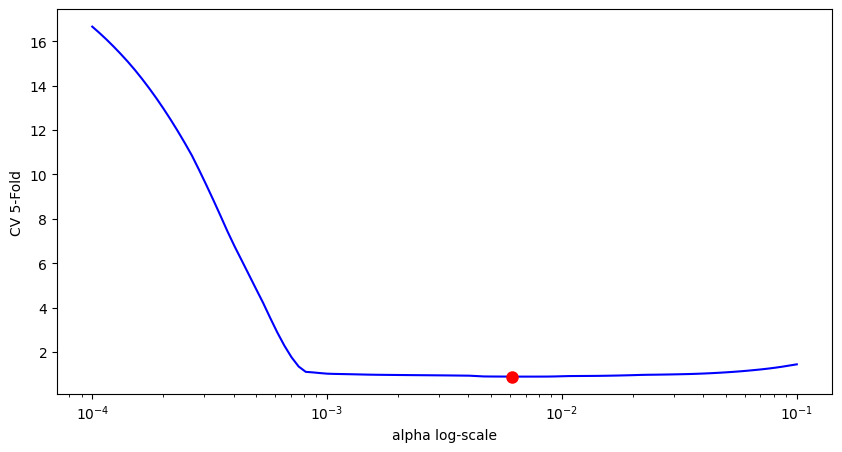

In [31]:
mses = np.mean(lassocv.mse_path_, axis=1)

# Plot CV error vs alpha
fig, ax = plt.subplots(figsize=(10,5));
ax.plot(lassocv.alphas_,mses, color='b');
ax.plot(lassocv.alpha_, np.min(mses), marker='o', color='r', markersize=8);
ax.set_xlabel('alpha log-scale');
ax.set_xscale('log')
ax.set_ylabel('CV 5-Fold');

In [32]:
pd.Series(lassocv.coef_.flatten(), index=X.columns)

x1     2.069583
x2     0.858339
x3    -3.688859
x4    -0.000000
x5    -0.294691
x6    -0.427344
x7    -0.000000
x8    -0.026924
x9    -0.000000
x10   -0.000000
dtype: float64

(f) Now generate a response vector Y according to the model $$Y = \beta_0 + \beta_7X^7 +\varepsilon$$, and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [45]:
X = np.random.normal(loc=0.0, scale=1.0, size=(100, 1))
X

array([[-0.72953353],
       [-1.04395817],
       [ 2.68473325],
       [-1.58199511],
       [ 0.86496107],
       [ 0.10666311],
       [ 1.27855223],
       [-0.47003053],
       [-1.17225985],
       [ 1.85521044],
       [ 2.32198601],
       [-0.86477437],
       [ 0.8518762 ],
       [-1.02826697],
       [ 0.89611855],
       [ 0.58086379],
       [-0.56416697],
       [-0.22492862],
       [-2.00798406],
       [-0.48278633],
       [-0.32284321],
       [-0.18168922],
       [-0.09485104],
       [-1.05519993],
       [ 1.7774315 ],
       [-0.81796698],
       [-1.32165603],
       [ 0.88400689],
       [ 1.24358391],
       [ 0.59792076],
       [ 1.01666109],
       [ 0.60493481],
       [ 1.15063971],
       [-0.76654645],
       [ 0.65211107],
       [ 0.45788651],
       [ 0.50699776],
       [-0.75467843],
       [-0.12549868],
       [-0.85850444],
       [ 1.20698972],
       [-0.98880271],
       [-2.12500935],
       [-0.16896669],
       [ 0.10364229],
       [-0

In [49]:
Y = 5 - X**7 + epsilon

In [50]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

cols = ['x'+str(i) for i in range(1, 11)] + ['Y']
X_df = pd.DataFrame(np.concatenate((X_poly,Y), axis=1), columns=cols)
X_df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,Y
0,-0.729534,0.532219,-0.388272,0.283257,-0.206646,0.150755,-0.109981,0.080235,-0.058534,0.042702,5.960409
1,-1.043958,1.089849,-1.137756,1.187770,-1.239982,1.294490,-1.351393,1.410798,-1.472814,1.537556,7.095275
2,2.684733,7.207793,19.351000,51.952274,139.477998,374.461217,1005.328479,2699.038791,7246.199172,19454.111821,-999.707422
3,-1.581995,2.502709,-3.959273,6.263550,-9.908906,15.675840,-24.799102,39.232059,-62.064926,98.186409,28.454509
4,0.864961,0.748158,0.647127,0.559740,0.484153,0.418774,0.362223,0.313309,0.271000,0.234404,5.569445


In [51]:
X = X_df.drop(['Y'], axis=1)
Y = X_df.Y

In [52]:
bestsub2 = find_best_subset(X, Y, 10, 'poly_bestsub_2')
bestsub2

100%|██████████| 10/10 [00:01<00:00,  6.16it/s]


,sub,model
0,[x7],<statsmodels.regression.linear_model.Regressio...
1,"[x7, x8]",<statsmodels.regression.linear_model.Regressio...
2,"[x4, x6, x7]",<statsmodels.regression.linear_model.Regressio...
3,"[x6, x7, x8, x9]",<statsmodels.regression.linear_model.Regressio...
4,"[x2, x6, x7, x8, x9]",<statsmodels.regression.linear_model.Regressio...
5,"[x1, x2, x4, x5, x6, x7]",<statsmodels.regression.linear_model.Regressio...
6,"[x2, x3, x4, x5, x6, x7, x9]",<statsmodels.regression.linear_model.Regressio...
7,"[x2, x3, x4, x5, x7, x8, x9, x10]",<statsmodels.regression.linear_model.Regressio...
8,"[x1, x2, x3, x5, x6, x7, x8, x9, x10]",<statsmodels.regression.linear_model.Regressio...
9,"[x1, x2, x3, x4, x5, x6, x7, x8, x9, x10]",<statsmodels.regression.linear_model.Regressio...


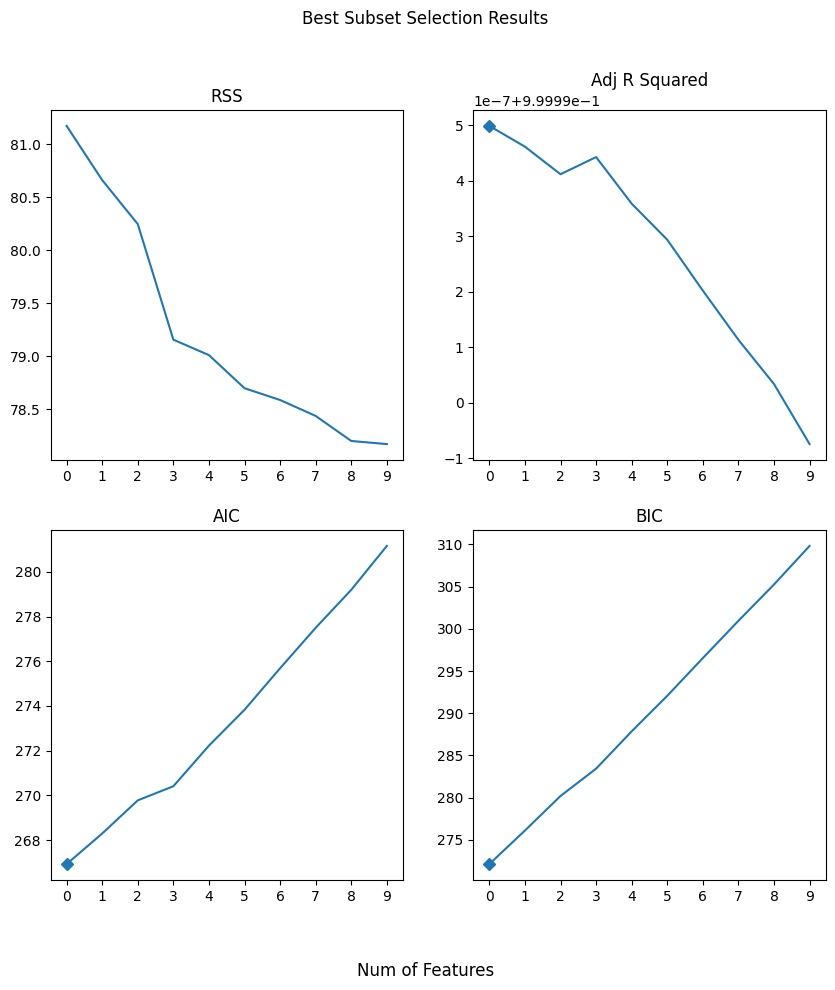

In [53]:
aic2 = [bestsub2.model[i].aic for i in range(0, len(bestsub2.model))]
bic2 = [bestsub2.model[i].bic for i in range(0, len(bestsub2.model))]
r2_adj2 = [bestsub2.model[i].rsquared_adj for i in range(0, len(bestsub2.model))]
rss2 = [bestsub2.model[i].ssr for i in range(0, len(bestsub2.model))]
fig, axes = plt.subplots(2, 2, sharex=False, sharey=False)
fig.set_figheight(10)
fig.set_figwidth(10)
fig.supxlabel('Num of Features')

fig.suptitle('Best Subset Selection Results')

axes[0, 0].plot(rss2)
axes[0, 0].set_title('RSS')
axes[0, 0].set_xticks(np.arange(0, 10, 1))

axes[0, 1].plot(r2_adj2, markevery=[np.argmax(r2_adj2)], marker='D')
axes[0, 1].set_title('Adj R Squared')
axes[0, 1].set_xticks(np.arange(0, 10, 1))

axes[1, 0].plot(aic2, markevery=[np.argmin(aic2)], marker='D')
axes[1, 0].set_title('AIC')
axes[1, 0].set_xticks(np.arange(0, 10, 1))

axes[1, 1].plot(bic2, markevery=[np.argmin(bic2)], marker='D')
axes[1, 1].set_title('BIC')
axes[1, 1].set_xticks(np.arange(0, 10, 1))

In [56]:
np.random.seed(5)
lassocv2 = LassoCV(n_alphas=400, cv=10, max_iter=10000)

lassocv2.fit(scale(X), Y.ravel())

C:\Users\benny\AppData\Local\Temp\ipykernel_1504\1554989786.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lassocv2.fit(scale(X), Y.ravel())


LassoCV(cv=10, max_iter=10000, n_alphas=400)

In [57]:
# optimal value of alpha
lassocv2.alpha_

0.2937792178299723

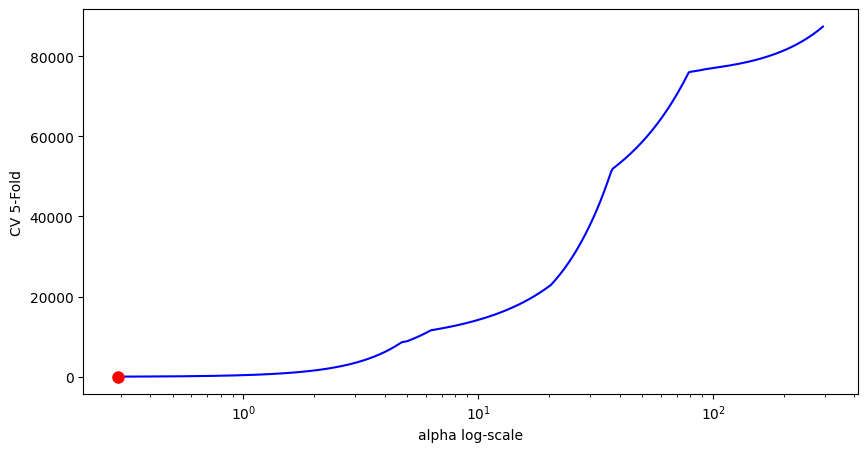

In [58]:
mses = np.mean(lassocv2.mse_path_, axis=1)

# Plot CV error vs alpha
fig, ax = plt.subplots(figsize=(10,5));
ax.plot(lassocv2.alphas_,mses, color='b');
ax.plot(lassocv2.alpha_, np.min(mses), marker='o', color='r', markersize=8);
ax.set_xlabel('alpha log-scale');
ax.set_xscale('log')
ax.set_ylabel('CV 5-Fold');

In [59]:
# Coefficient estimates of lasso model
pd.Series(lassocv2.coef_.flatten(), index=X.columns)

x1       0.000000
x2      -0.000000
x3      -0.000000
x4      -0.000000
x5     -12.354433
x6      -1.063588
x7    -261.241166
x8      -0.000000
x9     -19.269557
x10     -0.000000
dtype: float64